True label: 121
Predicted: 121


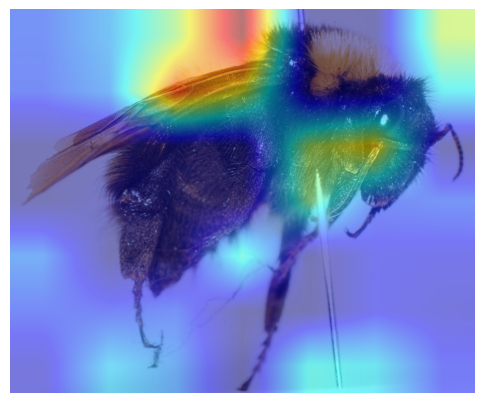

In [17]:
# =========================================================
# Minimal ConvNeXt + FinerCAM Script (Beemachine)
# =========================================================

import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------------
# CONFIG
# -----------------------------
MODEL_NAME = "convnext_nano.in12k"
IMAGE_SIZE = 224
DEVICE = "cuda:0"

DATA_DIR = "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
MODEL_WEIGHTS = "/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/convnext_nano.in12k_timm_new_dataset_logs/checkpoints/best_model.pth"

# -----------------------------
# Load CSV
# -----------------------------
test_df = pd.read_csv(f"{DATA_DIR}/test_labels.csv")

le = LabelEncoder()
train_df = pd.read_csv(f"{DATA_DIR}/train_aug_labels.csv")
le.fit(train_df["species"])
test_df["label"] = le.transform(test_df["species"])
num_classes = len(le.classes_)

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4925, 0.4475, 0.3490),
        std=(0.2392, 0.2265, 0.2213)
    )
])

# -----------------------------
# Load Model
# -----------------------------
device = torch.device(DEVICE)

model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=num_classes
)

state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# -----------------------------
# Select one test image
# -----------------------------
row = test_df.iloc[0]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

image_pil = Image.open(img_path).convert("RGB")
input_tensor = transform(image_pil).unsqueeze(0).to(device)

# -----------------------------
# Forward pass (optional check)
# -----------------------------
with torch.no_grad():
    output = model(input_tensor)
pred = output.argmax(dim=1).item()

print(f"True label: {label}")
print(f"Predicted: {pred}")

# -----------------------------
# FinerCAM Setup
# IMPORTANT: use last ConvNeXt stage
# -----------------------------
target_layers = [model.stages[-1]]

cam = FinerCAM(
    model=model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(label)]

# -----------------------------
# Generate CAM
# -----------------------------
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]  # remove batch dim

# -----------------------------
# Overlay (Correct Version)
# -----------------------------
rgb_img = np.array(image_pil).astype(np.float32) / 255.0

# Resize CAM to original image size
grayscale_cam = cv2.resize(
    grayscale_cam,
    (rgb_img.shape[1], rgb_img.shape[0])
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.axis("off")
plt.show()